# The command line and the FITS output

Everything `simulate_field` does is also available from the shell as `wcc-sim`. This
notebook runs the CLI on a real Gaia pointing (cached in `gaia_cache/`, so it works
offline) and dissects the multi-extension FITS file it writes.

**Requirements:** the `py313` conda env kernel (`wcc_etc` + `astroquery`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import wcc_etc
import wcc_sim

plt.style.use('gks')
TEAL, RED, AMBER = '#00798c', '#d1495b', '#edae49'

print(f'wcc_sim {wcc_sim.__version__} | wcc_etc {wcc_etc.__version__}')

import subprocess
import sys

def run(args):
    r = subprocess.run([sys.executable, '-m', 'wcc_sim.cli'] + args,
                       capture_output=True, text=True)
    print(r.stdout or r.stderr)
    assert r.returncode == 0, r.stderr
    return r

wcc_sim 0.1.0 | wcc_etc 0.6.0


## 1. `wcc-sim --help`

In [2]:
run(['--help']);

usage: wcc-sim [-h] --ra RA --dec DEC [--sensorfilter SENSORFILTER]
               [--focus {0,1,2}] [--exptime EXPTIME] [--n-reads N_READS]
               [--pa PA] [--jitter JITTER_SIGMA_MAS] [--mag-limit MAG_LIMIT]
               [--no-noise] [--no-clean] [--seed SEED] [--shape NY NX]
               [--stamp-npix STAMP_NPIX] [--cache-dir CACHE_DIR] -o OUTPUT

Simulate a WCC detector image of the Gaia field at (RA, Dec).

options:
  -h, --help            show this help message and exit
  --ra RA               pointing RA [deg, ICRS]
  --dec DEC             pointing Dec [deg, ICRS]
  --sensorfilter SENSORFILTER
                        wcc_etc sensorfilter, e.g. zwo:r, zwo:r+1, qcmos:bb
  --focus {0,1,2}       waves of defocus (default: sensorfilter's focus level)
  --exptime EXPTIME     total exposure [s]
  --n-reads N_READS     coadded frames
  --pa PA               position angle [deg E of N]
  --jitter JITTER_SIGMA_MAS
                        jitter sigma [mas]
  --mag-limit MAG_LI

## 2. Simulate a field from the shell

A 600×600 px cutout of a Kepler-field pointing at +1 wave defocus. `--cache-dir
gaia_cache` reuses the cone search shipped with the repository, so no network is
needed; `--seed` pins the noise realization.

In [3]:
run(['--ra', '291.017019', '--dec', '44.495843',
     '--sensorfilter', 'zwo:r', '--focus', '1',
     '--exptime', '90', '--seed', '42',
     '--shape', '600', '600', '--cache-dir', 'gaia_cache',
     '-o', 'cli_field_1wave.fits']);

Wrote cli_field_1wave.fits: 600x600 px, 7 sources, focus=1w, 0 saturated px



## 3. What is in the file

Four extensions: the ADU image (`SCI`, with WCS + provenance header), the per-pixel
saturation mask (`SATMASK`), the injected catalog (`CAT`), and the noiseless
expectation image (`CLEAN`, omit with `--no-clean`).

In [4]:
from astropy.io import fits

hdul = fits.open('cli_field_1wave.fits')
hdul.info()

Filename: cli_field_1wave.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SCI           1 PrimaryHDU      46   (600, 600)   float32   
  1  SATMASK       1 ImageHDU         8   (600, 600)   uint8   
  2  CAT           1 BinTableHDU     38   7R x 12C   [K, D, D, E, E, E, D, D, 3A, D, L, L]   
  3  CLEAN         1 ImageHDU         9   (600, 600)   float32   


In [5]:
hdr = hdul['SCI'].header
for card in ['RA_PNT', 'DEC_PNT', 'SENSORF', 'FOCUS', 'EXPTIME', 'NREADS',
             'JITTER', 'MAGLIM', 'SEED', 'NSRC', 'PLTSCL', 'GAIN', 'RDNOISE',
             'DARK', 'SKYRATE', 'WELLDEP', 'WCCSIMV', 'WCCETCV', 'BUNIT']:
    print(f'{card:8s} = {hdr[card]!r:>24}   / {hdr.comments[card]}')

RA_PNT   =               291.017019   / [deg] pointing RA (ICRS), array center
DEC_PNT  =                44.495843   / [deg] pointing Dec (ICRS), array center
SENSORF  =                  'zwo:r'   / wcc_etc sensorfilter (kind:band)
FOCUS    =                        1   / [waves] defocus (0=in-focus)
EXPTIME  =                     90.0   / [s] total exposure time
NREADS   =                        1   / coadded frames (ETC semantics)
JITTER   =                     10.0   / [mas] jitter Gaussian sigma
MAGLIM   =                     21.0   / Gaia G faint limit of injected sources
SEED     =                       42   / RNG seed (empty if None)
NSRC     =                        7   / number of injected sources
PLTSCL   =       16.869089722675366   / [mas/pix] plate scale
GAIN     =        0.261200000004368   / [e-/ADU] sensor gain
RDNOISE  =       3.0442890448219115   / [e-] read noise per frame
DARK     =     0.003070336749998594   / [e-/s/pix] dark current
SKYRATE  =     0.013643288040258

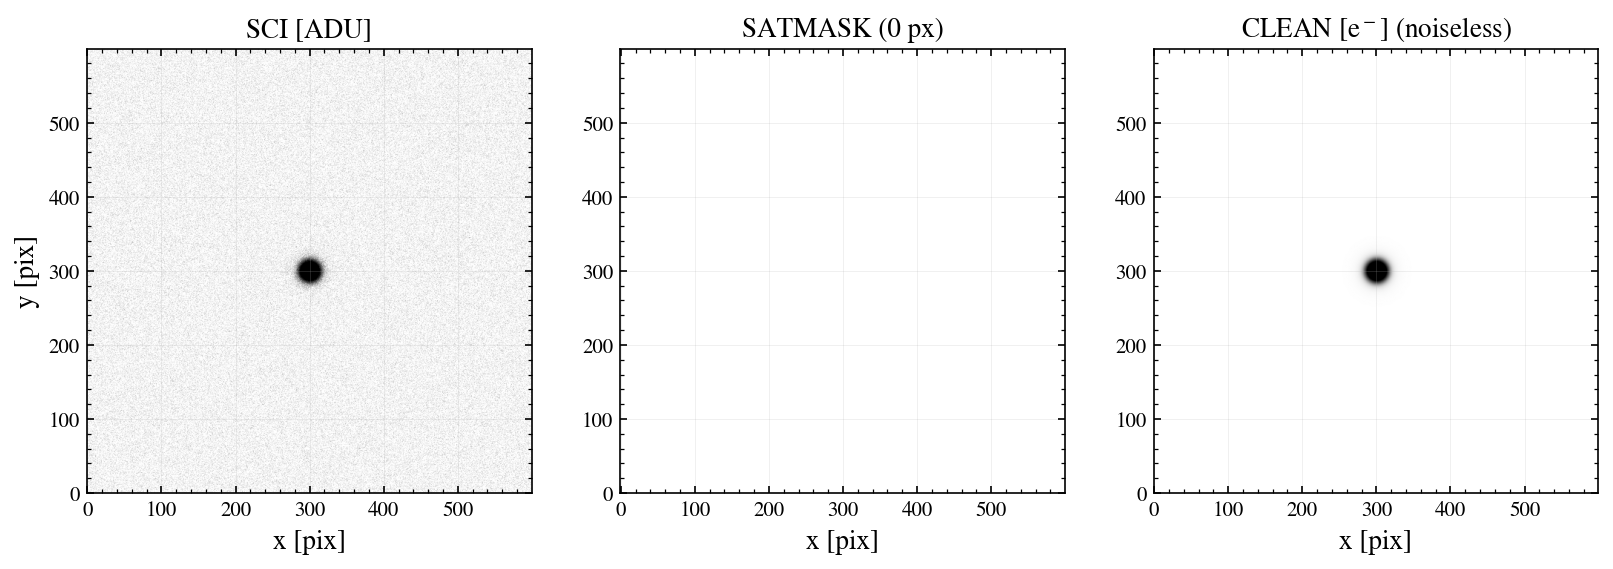

In [6]:
from astropy.visualization import simple_norm

sci = hdul['SCI'].data
sat = hdul['SATMASK'].data.astype(bool)
clean = hdul['CLEAN'].data

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
axes[0].imshow(sci, origin='lower', cmap='gray_r',
               norm=simple_norm(sci, 'asinh', percent=99.7))
axes[0].set_title(f'SCI [ADU]')
axes[1].imshow(sat, origin='lower', cmap='gray_r', interpolation='none')
axes[1].set_title(f'SATMASK ({sat.sum()} px)')
axes[2].imshow(clean, origin='lower', cmap='gray_r',
               norm=simple_norm(clean, 'asinh', percent=99.7))
axes[2].set_title('CLEAN [e$^-$] (noiseless)')
for ax in axes:
    ax.set_xlabel('x [pix]')
axes[0].set_ylabel('y [pix]')
plt.show()

## 4. The catalog extension

`CAT` carries every injected Gaia source with its pixel position, assigned spectral
type, count rate, and flags — everything needed to evaluate photometry or train on
the image.

In [7]:
from astropy.table import Table

cat = Table.read(hdul['CAT'])
cat.sort('phot_g_mean_mag')
print(f'{len(cat)} sources | {np.asarray(cat["in_image"], bool).sum()} in frame | '
      f'{np.asarray(cat["saturated"], bool).sum()} flagged saturated')
cat[:8]

7 sources | 1 in frame | 0 flagged saturated


source_id,ra,dec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,x,y,spt,rate_e_s,in_image,saturated
,deg,deg,mag,mag,mag,,,,,,
int64,float64,float64,float32,float32,float32,float64,float64,str3,float64,bool,bool
2126245691858425728,291.0211043559742,44.4969746878879,16.742466,17.188572,16.14136,-322.37821688720305,541.0268749834006,K2V,7955.616417257058,False,False
2126245687559826048,291.02327197511016,44.49729688452118,18.237642,18.737148,17.609856,-652.330771323393,609.8071028426876,K2V,2007.2585162224102,False,False
2126245588779207936,291.0170189106795,44.495842626555834,18.262655,18.628824,17.74546,299.51359674851705,299.4203039963873,G5V,1914.1767541894128,True,False
2126245794937637632,291.01408663507874,44.4978801095047,18.886478,19.299976,18.357029,745.8614834546491,734.2436280732969,G8V,1088.153271381706,False,False
2126245790639029504,291.0104300591018,44.49512296717736,19.576889,19.926746,19.043058,1302.5090313339151,145.87959946750735,G5V,570.5431898419027,False,False
2126245584480594432,291.01765804648454,44.493791125062245,19.900595,21.206516,18.84191,202.21819950324004,-138.3863048764921,M2V,317.40402190531125,False,False
2126245584477751168,291.0218141943379,44.49254029274426,20.22042,21.373112,19.00277,-430.4862472893402,-405.3029976034127,M2V,236.41878172548758,False,False


## 5. Astrometric closure through the file

The WCS in the `SCI` header must map the catalog's (ra, dec) back onto its stored
pixel positions — a full round-trip through the FITS file.

In [8]:
from astropy.wcs import WCS

wcs = WCS(hdr)
x, y = wcs.world_to_pixel_values(np.asarray(cat['ra'], float),
                                 np.asarray(cat['dec'], float))
err = np.hypot(x - cat['x'], y - cat['y']).max()
print(f'max |WCS(ra,dec) - (x,y)| = {err:.2e} px')
assert err < 1e-3
hdul.close()

max |WCS(ra,dec) - (x,y)| = 2.81e-12 px


## Summary

- `wcc-sim` exposes the whole pipeline from the shell; `--cache-dir` makes reruns
  offline and `--seed` makes them reproducible.
- The FITS file is self-describing: WCS + full provenance in the `SCI` header,
  per-pixel `SATMASK`, the injected `CAT`, and a noiseless `CLEAN` image.
- See the CLI page of the documentation for the full option table and a cookbook,
  and `scripts/` for ready-to-run examples.